In [9]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras

In [10]:
from tensorflow.keras.applications import VGG16

# Load the base model without the top classification layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))


In [11]:
print(base_model.summary())

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

None


In [12]:
# for layer in base_model.layers:
#     print(layer.name, layer.trainable)


In [13]:
# Freeze the pretrained VGG16 base for transfer learning
# (This keeps the ImageNet weights fixed and trains only your new heads.)
base_model.trainable = False
print('Base model trainable:', base_model.trainable)
print('Trainable layers in base:', sum(int(l.trainable) for l in base_model.layers), '/', len(base_model.layers))

Base model trainable: False
Trainable layers in base: 0 / 19


In [14]:
# for layer in base_model.layers:
#     print(layer.name, layer.trainable)

In [15]:
# from tensorflow.keras import layers, models

# x = layers.Flatten()(base_model.output) ## Flattens the output of the base model to a 1D vector
# x = layers.Dense(128, activation='relu')(x) ## Adds a fully connected layer with 128 neurons and ReLU activation

# ## This dropout layer was added onafter the first run as we were seeing signs of overfitting in the training process. It randomly sets 50% of the input units to 0 at each update during training, which helps prevent overfitting by reducing reliance on specific neurons and encouraging the model to learn more robust features.
# # x = layers.Dropout(0.5)(x) ## Adds a dropout layer with a 50% dropout rate to prevent overfitting

# num_classes = 3  # tank/btr, cope cage/no cope cage, not destroyed/destroyed
# predictions = layers.Dense(num_classes, activation='softmax')(x) 

# model = models.Model(inputs=base_model.input, outputs=predictions)


In [ ]:
# print(model.summary())

In [18]:
# from tensorflow.keras.optimizers import Adam

# model.compile(optimizer=Adam(learning_rate=0.0001), 
#               loss='categorical_crossentropy', 
#               metrics=['accuracy'])

In [20]:
# print(model.summary())

In [21]:
df = pd.read_csv('dataset/image_data.csv')

# Drop rows whose image file is missing (prevents tf.io.read_file crashes)
from pathlib import Path
_img_dir = Path('dataset/images')
_exists = df['filename'].astype(str).map(lambda n: (_img_dir / n).exists())
_missing = (~_exists).sum()
if _missing:
    print(f"Warning: dropping {_missing} rows with missing files")
    df = df[_exists].reset_index(drop=True)

# Ensure expected dtypes
df['vehicle_type'] = df['vehicle_type'].astype(str)
df['cope_cage'] = df['cope_cage'].astype(int)
df['destroyed'] = df['destroyed'].astype(int)

print('Rows after cleanup:', len(df))
# df

Rows after cleanup: 130


In [22]:
vehicle_list = sorted(df['vehicle_type'].unique())
num_vehicle_classes = len(vehicle_list)

In [23]:

# Map vehicle string labels to sequential integers (e.g., 'btr' -> 0, 'tank' -> 1)
label_to_index = {name: i for i, name in enumerate(vehicle_list)}
df['vehicle_id'] = df['vehicle_type'].map(label_to_index)

In [24]:
print(f"Detected {num_vehicle_classes} unique vehicle classes: {vehicle_list}")


Detected 2 unique vehicle classes: ['btr', 'tank']


In [25]:
def process_path(filename, vehicle_id, cope_cage, destroyed):
    """Processes image paths on-the-fly without overloading computer RAM."""
    # Ensure filename is a scalar string tensor (some pipelines can introduce extra dims)
    filename = tf.reshape(tf.squeeze(filename), [])
    tf.debugging.assert_rank(filename, 0, message='filename must be scalar')
    img_path = tf.strings.join(['dataset/images/', filename])
    tf.debugging.assert_rank(img_path, 0, message='img_path must be scalar')

    # Read bytes
    img_bytes = tf.io.read_file(img_path)
    tf.debugging.assert_rank(img_bytes, 0, message='img_bytes must be scalar')

    # Decode (handle JPEG + WEBP explicitly)
    lower = tf.strings.lower(filename)
    is_webp = tf.strings.regex_full_match(lower, r'.*\.webp')

    def _decode_webp():
        return tf.io.decode_webp(img_bytes)

    def _decode_jpeg():
        return tf.image.decode_jpeg(img_bytes, channels=3)

    img = tf.cond(is_webp, _decode_webp, _decode_jpeg)

    # Defensive: ensure [H, W, C]
    shape = tf.shape(img)
    img = tf.reshape(img, [shape[-3], shape[-2], shape[-1]])
    img = tf.image.resize(img, (150, 150))
    img = img / 255.0  # Scale pixel values to [0, 1]

    return img, {
        'type_output_layer': vehicle_id,
        'cage_output_layer': cope_cage,
        'status_output_layer': destroyed,
    }


# Convert Pandas columns into a high-speed TensorFlow Dataset object
dataset = tf.data.Dataset.from_tensor_slices((
    df['filename'].values,
    df['vehicle_id'].values,
    df['cope_cage'].values,
    df['destroyed'].values
))

# Apply transformations and set up processing queue
# Adjust batch size (32) depending on your GPU memory constraints
train_generator = dataset.map(process_path).batch(32).prefetch(tf.data.AUTOTUNE)


In [26]:
# # --- K-Fold Cross Validation (drop-in replacement for the single 80/20 split + fit) ---

# import numpy as np
# from sklearn.model_selection import StratifiedKFold

# BATCH_SIZE = 32
# MAX_EPOCHS = 50
# SEED = 42

# def make_dataset(df_subset: pd.DataFrame, training: bool) -> tf.data.Dataset:
#     ds = tf.data.Dataset.from_tensor_slices((
#         df_subset["filename"].values,
#         df_subset["vehicle_id"].values,
#         df_subset["cope_cage"].values,
#         df_subset["destroyed"].values,
#     ))
#     if training:
#         ds = ds.shuffle(len(df_subset), seed=SEED, reshuffle_each_iteration=True)
#     ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
#     ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
#     return ds

# def build_model(num_vehicle_classes: int) -> tf.keras.Model:
#     base_model = tf.keras.applications.VGG16(
#         weights="imagenet",
#         include_top=False,
#         input_shape=(150, 150, 3),
#     )
#     base_model.trainable = False

#     x = tf.keras.layers.Flatten()(base_model.output)
#     x = tf.keras.layers.Dense(128, activation="relu")(x)
#     # x = tf.keras.layers.Dropout(0.5)(x)  # consider enabling for overfitting

#     type_head = tf.keras.layers.Dense(
#         num_vehicle_classes, activation="softmax", name="type_output_layer"
#     )(x)
#     cage_head = tf.keras.layers.Dense(
#         1, activation="sigmoid", name="cage_output_layer"
#     )(x)
#     status_head = tf.keras.layers.Dense(
#         1, activation="sigmoid", name="status_output_layer"
#     )(x)

#     model = tf.keras.Model(
#         inputs=base_model.input,
#         outputs=[type_head, cage_head, status_head],
#     )

#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#         loss={
#             "type_output_layer": tf.keras.losses.SparseCategoricalCrossentropy(),
#             "cage_output_layer": tf.keras.losses.BinaryCrossentropy(),
#             "status_output_layer": tf.keras.losses.BinaryCrossentropy(),
#         },
#         metrics={
#             "type_output_layer": "accuracy",
#             "cage_output_layer": "accuracy",
#             "status_output_layer": "accuracy",
#         },
#     )
#     return model

# # Shuffle once (reproducible)
# df_cv = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# # Stratify on combined binary labels (00,01,10,11 -> 0..3)
# strat_key = (df_cv["cope_cage"].astype(int) * 2 + df_cv["destroyed"].astype(int)).to_numpy()

# # Choose K safely for tiny datasets (StratifiedKFold requires >= K samples in each stratum)
# counts = pd.Series(strat_key).value_counts()
# k = min(5, int(counts.min()))
# if k < 2:
#     raise ValueError(
#         f"Not enough samples per (cope_cage,destroyed) group for stratified K-fold. "
#         f"Group counts:\n{counts}\n"
#         f"Collect more data or reduce stratification complexity."
#     )

# print("Stratum counts (combined cope_cage/destroyed):")
# print(counts.sort_index())
# print(f"Using StratifiedKFold with n_splits={k}")

# skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)

# fold_scores = []
# metrics_names = None

# for fold, (train_idx, val_idx) in enumerate(skf.split(df_cv, strat_key), start=1):
#     print(f"\n===== Fold {fold}/{k} =====")

#     train_df_fold = df_cv.iloc[train_idx].reset_index(drop=True)
#     val_df_fold = df_cv.iloc[val_idx].reset_index(drop=True)

#     train_gen = make_dataset(train_df_fold, training=True)
#     val_gen = make_dataset(val_df_fold, training=False)

#     tf.keras.backend.clear_session()
#     model = build_model(num_vehicle_classes)

#     callbacks = [
#         tf.keras.callbacks.EarlyStopping(
#             monitor="val_loss",
#             patience=3,
#             restore_best_weights=True,
#         ),
#     ]

#     history = model.fit(
#         train_gen,
#         validation_data=val_gen,
#         epochs=MAX_EPOCHS,
#         callbacks=callbacks,
#         verbose=1,
#     )

#     # Evaluate fold
#     scores = model.evaluate(val_gen, verbose=0)
#     metrics_names = model.metrics_names
#     fold_scores.append(scores)

#     best_val = float(np.min(history.history["val_loss"]))
#     print(f"Best val_loss this fold: {best_val:.4f}")
#     print("Fold metrics_names:", metrics_names)
#     print("Fold scores:", scores)

# # Summarize CV results
# fold_scores = np.asarray(fold_scores, dtype=float)
# print("\n===== Cross-Validation Summary =====")
# for i, name in enumerate(metrics_names):
#     col = fold_scores[:, i]
#     print(f"{name:35s} mean={col.mean():.4f}  std={col.std(ddof=1):.4f}")

In [27]:
# for item in train_generator.take(1):
    # print(item[1])

In [28]:
# for item in train_generator.take(1):
#     images, labels = item
#     print("Image batch shape:", images.shape)
#     print("Vehicle type labels (type_output_layer):", labels['type_output_layer'])
#     print("Cope cage labels (cage_output_layer):", labels['cage_output_layer'])
#     print("Battle damage labels (status_output_layer):", labels['status_output_layer'])

In [29]:
# # Sanity-check validation generator
# for item in val_generator.take(1):
#     images, labels = item
#     print('VAL image batch shape:', images.shape)
#     print('VAL label keys:', list(labels.keys()))


In [30]:
# help(layers.Dense)

In [31]:
from tensorflow.keras import layers, models

# Build a fresh multi-head classifier on top of the frozen VGG16 base.
# This ensures the vehicle-type head output size matches `num_vehicle_classes`.
x = layers.Flatten()(base_model.output)
x = layers.Dense(128, activation='relu')(x)

type_head = layers.Dense(num_vehicle_classes, activation='softmax', name='type_output_layer')(x)

# Head 2: Binary classification for cope cage presence
cage_head = layers.Dense(1, activation='sigmoid', name='cage_output_layer')(x)

# Head 3: Binary classification for battle damage condition
status_head = layers.Dense(1, activation='sigmoid', name='status_output_layer')(x)

# Tie base inputs and the three distinct outputs into a unified model
model = models.Model(inputs=base_model.input, outputs=[type_head, cage_head, status_head])

print('Rebuilt model with num_vehicle_classes =', num_vehicle_classes)


Rebuilt model with num_vehicle_classes = 2


In [32]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    # Map specific loss rules to their respective dictionary keys
    loss={
        'type_output_layer': tf.keras.losses.SparseCategoricalCrossentropy(),
        'cage_output_layer': tf.keras.losses.BinaryCrossentropy(),
        'status_output_layer': tf.keras.losses.BinaryCrossentropy()
    },
    # Independently evaluate individual accuracy rates during execution
    metrics={
        'type_output_layer': 'accuracy',
        'cage_output_layer': 'accuracy',
        'status_output_layer': 'accuracy'
    }
)

In [33]:
# model.summary()


In [34]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Split into 80% Training and 20% Validation
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
val_df = df.iloc[split_idx:]

# --- Train Generator ---
train_dataset = tf.data.Dataset.from_tensor_slices((
    train_df['filename'].values, train_df['vehicle_id'].values, train_df['cope_cage'].values, train_df['destroyed'].values
))
train_generator = train_dataset.map(process_path).batch(32).prefetch(tf.data.AUTOTUNE)

# --- Validation Generator ---
val_dataset = tf.data.Dataset.from_tensor_slices((
    val_df['filename'].values, val_df['vehicle_id'].values, val_df['cope_cage'].values, val_df['destroyed'].values
))
val_generator = val_dataset.map(process_path).batch(32).prefetch(tf.data.AUTOTUNE)


In [35]:
# # Debug: verify shapes/types going into from_tensor_slices
# print('train_df filename values shape:', train_df['filename'].values.shape, 'dtype:', train_df['filename'].values.dtype)
# print('val_df filename values shape:', val_df['filename'].values.shape, 'dtype:', val_df['filename'].values.dtype)
# print('first train filename repr:', repr(train_df['filename'].values[0]), 'type:', type(train_df['filename'].values[0]))
# print('first val filename repr:', repr(val_df['filename'].values[0]), 'type:', type(val_df['filename'].values[0]))


In [36]:
# # Debug: inspect raw tf.data elements BEFORE map(process_path)
# print('train_dataset.element_spec:', train_dataset.element_spec)
# raw = next(iter(train_dataset.take(1)))
# raw_filename = raw[0]
# print('raw filename tensor:', raw_filename)
# print('raw filename shape:', raw_filename.shape)


In [37]:
# # Debug: inspect validation dataset/generator specs (no execution)
# print('val_dataset.element_spec:', val_dataset.element_spec)
# print('val_generator.element_spec:', val_generator.element_spec)


In [38]:
# Define how many times the model cycles through your entire dataset
EPOCHS = 20

# callbacks = [
#     tf.keras.callbacks.EarlyStopping(
#         monitor="val_loss",
#         patience=3,
#         restore_best_weights=True
#     ),
# #     tf.keras.callbacks.ModelCheckpoint(
# #         "best_model.keras",
# #         monitor="val_loss",
# #         save_best_only=True
# #     ),
# ]

print("Starting training pipeline...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    # callbacks=callbacks
)
print("Training complete!")


Starting training pipeline...
Epoch 1/20


I0000 00:00:1779977687.370363   63613 service.cc:153] XLA service 0x7342b4035cb0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779977687.370388   63613 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1779977687.441448   63613 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - cage_output_layer_accuracy: 0.7212 - cage_output_layer_loss: 0.6151 - loss: 1.9859 - status_output_layer_accuracy: 0.6442 - status_output_layer_loss: 0.6767 - type_output_layer_accuracy: 0.4904 - type_output_layer_loss: 0.6947 - val_cage_output_layer_accuracy: 0.6923 - val_cage_output_layer_loss: 0.6181 - val_loss: 1.8099 - val_status_output_layer_accuracy: 0.7692 - val_status_output_layer_loss: 0.6049 - val_type_output_layer_accuracy: 0.7692 - val_type_output_layer_loss: 0.5869
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - cage_output_layer_accuracy: 0.7308 - cage_output_layer_loss: 0.5486 - loss: 1.6913 - status_output_layer_accuracy: 0.7596 - status_output_layer_loss: 0.5771 - type_output_layer_accuracy: 0.7981 - type_output_layer_loss: 0.5321 - val_cage_output_layer_accuracy: 0.6923 - val_cage_output_layer_loss: 0.6025 - val_loss: 1.7393 - val_status_output_layer_accuracy: 0.8077 - val_status_output_layer_loss: 0.6027 - val_type_output_laye

In [39]:
# Compare distributions across splits
display(train_df["vehicle_type"].value_counts())
display(val_df["vehicle_type"].value_counts())

print("cope_cage mean (train/val):", train_df["cope_cage"].mean(), val_df["cope_cage"].mean())
print("destroyed mean (train/val):", train_df["destroyed"].mean(), val_df["destroyed"].mean())

vehicle_type
btr     53
tank    51
Name: count, dtype: int64

vehicle_type
tank    16
btr     10
Name: count, dtype: int64

cope_cage mean (train/val): 0.27884615384615385 0.3076923076923077
destroyed mean (train/val): 0.3557692307692308 0.19230769230769232


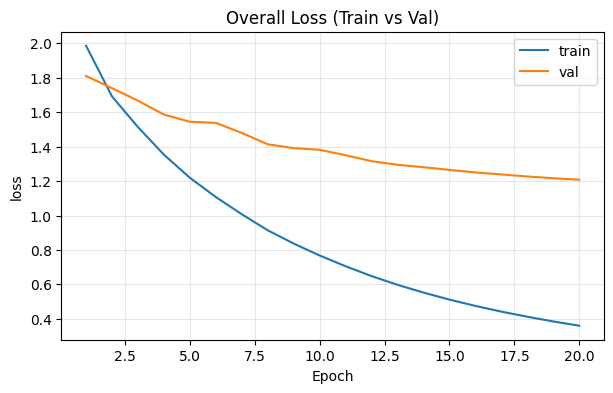

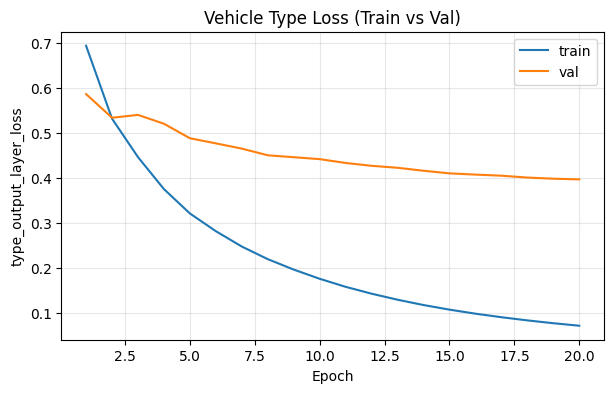

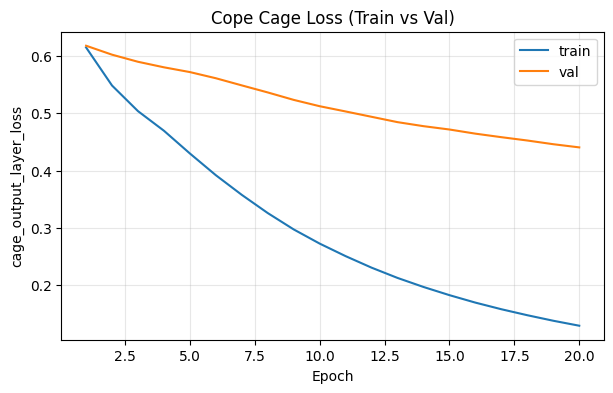

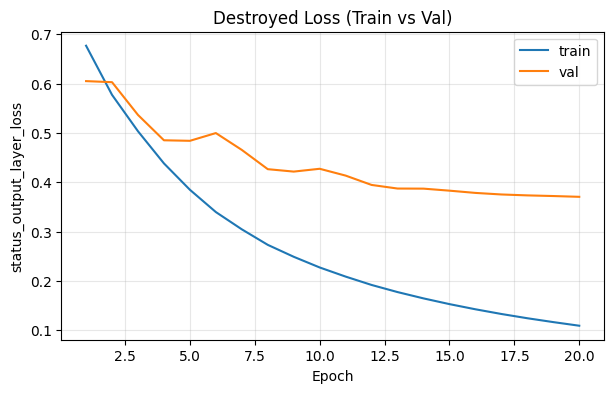

In [40]:
import matplotlib.pyplot as plt

hist = history.history
epochs = range(1, len(hist["loss"]) + 1)

def plot_train_vs_val(key: str, title: str = None):
    train_key = key
    val_key = f"val_{key}"
    if train_key not in hist or val_key not in hist:
        print(f"Missing keys: {train_key!r} or {val_key!r}. Available keys: {list(hist.keys())}")
        return

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, hist[train_key], label="train")
    plt.plot(epochs, hist[val_key], label="val")
    plt.xlabel("Epoch")
    plt.ylabel(key)
    plt.title(title or f"Train vs Val: {key}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Overall combined loss (sum of the 3 head losses)
plot_train_vs_val("loss", "Overall Loss (Train vs Val)")

# Per-head losses
plot_train_vs_val("type_output_layer_loss", "Vehicle Type Loss (Train vs Val)")
plot_train_vs_val("cage_output_layer_loss", "Cope Cage Loss (Train vs Val)")
plot_train_vs_val("status_output_layer_loss", "Destroyed Loss (Train vs Val)")

In [41]:

import matplotlib


plt = matplotlib.pyplot

In [42]:
print(history.history['cage_output_layer_loss'])
cage_loss = history.history['cage_output_layer_loss']
destroyed_loss = history.history['status_output_layer_loss']

[0.615096926689148, 0.5485903024673462, 0.5038524866104126, 0.46961265802383423, 0.42991337180137634, 0.39194929599761963, 0.3576146364212036, 0.3258384168148041, 0.2972632944583893, 0.27252906560897827, 0.25061193108558655, 0.23049284517765045, 0.21255947649478912, 0.19678205251693726, 0.18247947096824646, 0.1694507747888565, 0.15789282321929932, 0.1474391371011734, 0.13778844475746155, 0.129114031791687]


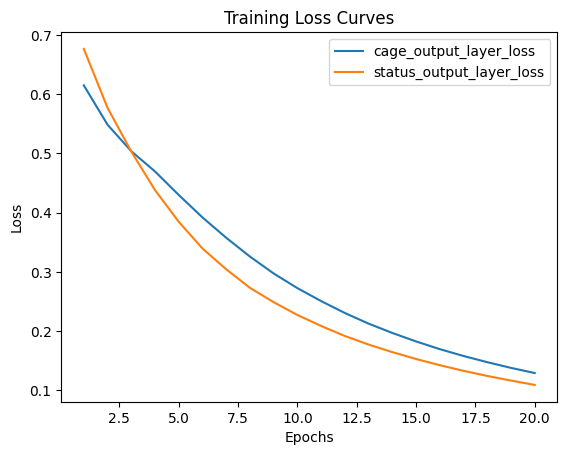

In [43]:
x_axis = range(1, EPOCHS + 1)
cage_y_axis = cage_loss
plt.plot(x_axis, cage_y_axis, label='cage_output_layer_loss')
plt.plot(x_axis, destroyed_loss, label='status_output_layer_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Curves')
plt.legend()
plt.show()


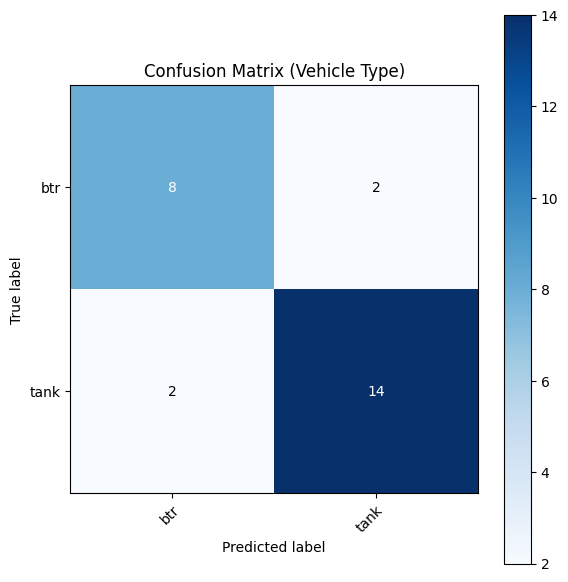

In [44]:
# Confusion matrix for vehicle type (type_output_layer) on the validation set
import numpy as np
import matplotlib.pyplot as plt

# If you restarted the kernel, re-run the training cell first so `model` and `val_generator` exist.
type_true = []
for _, y in val_generator:
    type_true.append(y['type_output_layer'].numpy())
type_true = np.concatenate(type_true, axis=0)

preds = model.predict(val_generator, verbose=0)
if isinstance(preds, (list, tuple)):
    type_probs = preds[0]
elif isinstance(preds, dict):
    type_probs = preds['type_output_layer']
else:
    raise TypeError(f'Unexpected predict output type: {type(preds)}')

type_pred = np.argmax(type_probs, axis=1)
cm = tf.math.confusion_matrix(type_true, type_pred, num_classes=num_vehicle_classes).numpy()

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm, cmap='Blues')
ax.figure.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(num_vehicle_classes),
    yticks=np.arange(num_vehicle_classes),
    xticklabels=vehicle_list,
    yticklabels=vehicle_list,
    xlabel='Predicted label',
    ylabel='True label',
    title='Confusion Matrix (Vehicle Type)'
 )
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# Write counts in each cell
threshold = cm.max() / 2.0 if cm.max() else 0.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > threshold else 'black')

fig.tight_layout()
plt.show()


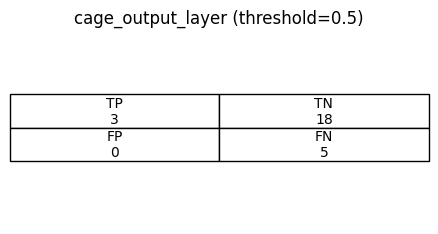

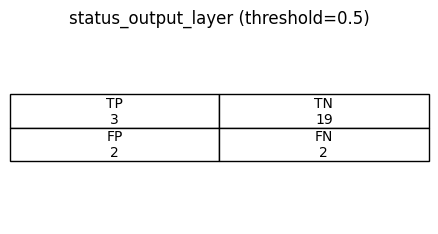

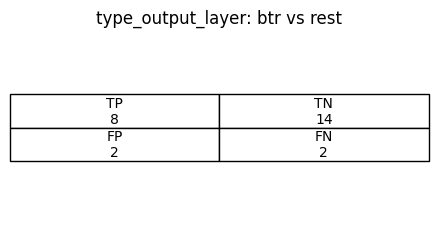

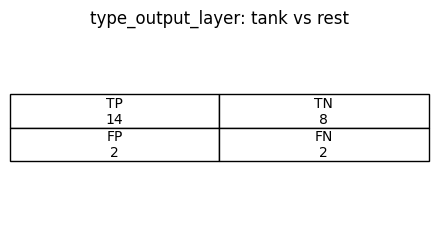

In [45]:
# TP / TN / FP / FN as a 2x2 graphic table (TP TN / FP FN) for the binary heads,
# plus one-vs-rest TP/TN/FP/FN tables for the multi-class vehicle type head.
import numpy as np
import matplotlib.pyplot as plt

def tp_tn_fp_fn(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    return tp, tn, fp, fn

def plot_binary_table(title, tp, tn, fp, fn):
    cell_text = [
        [f"TP\n{tp}", f"TN\n{tn}"],
        [f"FP\n{fp}", f"FN\n{fn}"],
    ]
    fig, ax = plt.subplots(figsize=(4.5, 2.5))
    ax.axis('off')
    table = ax.table(cellText=cell_text, loc='center', cellLoc='center')
    table.scale(1.2, 2.0)
    ax.set_title(title)
    plt.show()

# Collect true labels from the validation generator (all heads)
type_true = []
cage_true = []
status_true = []
for _, y in val_generator:
    type_true.append(y['type_output_layer'].numpy())
    cage_true.append(y['cage_output_layer'].numpy())
    status_true.append(y['status_output_layer'].numpy())
type_true = np.concatenate(type_true, axis=0).reshape(-1)
cage_true = np.concatenate(cage_true, axis=0).reshape(-1)
status_true = np.concatenate(status_true, axis=0).reshape(-1)

# Get predicted probabilities from the model
preds = model.predict(val_generator, verbose=0)
if isinstance(preds, (list, tuple)):
    type_probs, cage_prob, status_prob = preds
elif isinstance(preds, dict):
    type_probs = preds['type_output_layer']
    cage_prob = preds['cage_output_layer']
    status_prob = preds['status_output_layer']
else:
    raise TypeError(f'Unexpected predict output type: {type(preds)}')

type_probs = np.asarray(type_probs)
type_pred = np.argmax(type_probs, axis=1).reshape(-1)
cage_prob = np.asarray(cage_prob).reshape(-1)
status_prob = np.asarray(status_prob).reshape(-1)

thr = 0.5

# --- Binary heads ---
tp, tn, fp, fn = tp_tn_fp_fn(cage_true, cage_prob, threshold=thr)
plot_binary_table(f"cage_output_layer (threshold={thr})", tp, tn, fp, fn)

tp, tn, fp, fn = tp_tn_fp_fn(status_true, status_prob, threshold=thr)
plot_binary_table(f"status_output_layer (threshold={thr})", tp, tn, fp, fn)

# --- Vehicle type head (multi-class): one-vs-rest per class ---
for class_idx, class_name in enumerate(vehicle_list):
    y_true_bin = (type_true == class_idx).astype(int)
    y_pred_bin = (type_pred == class_idx).astype(int)
    tp, tn, fp, fn = tp_tn_fp_fn(y_true_bin, y_pred_bin, threshold=0.5)
    plot_binary_table(
        f"type_output_layer: {class_name} vs rest",
        tp, tn, fp, fn,
    )

In [46]:
# --- Metrics helpers (accuracy / precision / recall / F1) ---
import numpy as np
import pandas as pd


def _safe_div(numer: float, denom: float) -> float:
    return float(numer) / float(denom) if denom else 0.0


def binary_metrics_from_probs(y_true, y_prob, threshold: float = 0.5):
    """Compute binary accuracy/precision/recall/F1 given true labels and predicted probabilities."""
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    accuracy = _safe_div(tp + tn, tp + tn + fp + fn)
    precision = _safe_div(tp, tp + fp)
    recall = _safe_div(tp, tp + fn)
    f1 = _safe_div(2 * precision * recall, precision + recall) if (precision + recall) else 0.0

    return {
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "threshold": float(threshold),
        "support": int(tp + tn + fp + fn),
    }


def multiclass_metrics_from_cm(cm: np.ndarray, class_names):
    """Per-class precision/recall/F1 + overall accuracy from a confusion matrix."""
    cm = np.asarray(cm, dtype=np.int64)
    class_names = list(class_names)

    total = int(cm.sum())
    correct = int(np.trace(cm))
    overall_acc = _safe_div(correct, total)

    per_rows = []
    supports = cm.sum(axis=1)
    preds = cm.sum(axis=0)

    for i, name in enumerate(class_names):
        tp = int(cm[i, i])
        fp = int(preds[i] - tp)
        fn = int(supports[i] - tp)
        precision = _safe_div(tp, tp + fp)
        recall = _safe_div(tp, tp + fn)
        f1 = _safe_div(2 * precision * recall, precision + recall) if (precision + recall) else 0.0
        per_rows.append(
            {
                "class": name,
                "support": int(supports[i]),
                "precision": precision,
                "recall": recall,
                "f1": f1,
            }
        )

    per_df = pd.DataFrame(per_rows)
    macro = per_df[["precision", "recall", "f1"]].mean(numeric_only=True)
    weights = per_df["support"].to_numpy()
    weighted = (per_df[["precision", "recall", "f1"]].to_numpy() * weights[:, None]).sum(axis=0) / max(
        1, weights.sum()
    )

    summary_df = pd.DataFrame(
        [
            {
                "avg": "overall",
                "accuracy": overall_acc,
                "precision": np.nan,
                "recall": np.nan,
                "f1": np.nan,
                "support": total,
            },
            {
                "avg": "macro",
                "accuracy": np.nan,
                "precision": float(macro["precision"]),
                "recall": float(macro["recall"]),
                "f1": float(macro["f1"]),
                "support": total,
            },
            {
                "avg": "weighted",
                "accuracy": np.nan,
                "precision": float(weighted[0]),
                "recall": float(weighted[1]),
                "f1": float(weighted[2]),
                "support": total,
            },
        ]
    )

    return per_df, summary_df


In [47]:
# --- Compute metrics on the validation set for each head ---

# Collect true labels from the validation generator
_type_true = []
_cage_true = []
_status_true = []

for _, y in val_generator:
    _type_true.append(y["type_output_layer"].numpy())
    _cage_true.append(y["cage_output_layer"].numpy())
    _status_true.append(y["status_output_layer"].numpy())

_type_true = np.concatenate(_type_true, axis=0).reshape(-1)
_cage_true = np.concatenate(_cage_true, axis=0).reshape(-1)
_status_true = np.concatenate(_status_true, axis=0).reshape(-1)

# Predict probabilities for all heads
_preds = model.predict(val_generator, verbose=0)
if isinstance(_preds, (list, tuple)):
    _type_probs, _cage_prob, _status_prob = _preds
elif isinstance(_preds, dict):
    _type_probs = _preds["type_output_layer"]
    _cage_prob = _preds["cage_output_layer"]
    _status_prob = _preds["status_output_layer"]
else:
    raise TypeError(f"Unexpected predict output type: {type(_preds)}")

_type_probs = np.asarray(_type_probs)
_cage_prob = np.asarray(_cage_prob).reshape(-1)
_status_prob = np.asarray(_status_prob).reshape(-1)

# -----------------
# 1) Vehicle type head (multi-class; in your dataset it should usually be 2 classes)
_type_pred = np.argmax(_type_probs, axis=1).reshape(-1)
_cm_type = tf.math.confusion_matrix(_type_true, _type_pred, num_classes=num_vehicle_classes).numpy()

per_class_df, summary_df = multiclass_metrics_from_cm(_cm_type, vehicle_list)
print("Vehicle type head metrics (from confusion matrix)")
display(per_class_df)
display(summary_df)

# -----------------
# 2) Binary heads (cope cage + destroyed)
THRESHOLD = 0.5

rows = []
rows.append({"head": "cage_output_layer", **binary_metrics_from_probs(_cage_true, _cage_prob, threshold=THRESHOLD)})
rows.append({"head": "status_output_layer", **binary_metrics_from_probs(_status_true, _status_prob, threshold=THRESHOLD)})

bin_df = pd.DataFrame(rows)
print(f"Binary heads metrics (threshold={THRESHOLD})")
display(bin_df[["head", "accuracy", "precision", "recall", "f1", "tp", "tn", "fp", "fn", "support"]])


Vehicle type head metrics (from confusion matrix)


,class,support,precision,recall,f1
0,btr,10,0.800,0.800,0.800
1,tank,16,0.875,0.875,0.875


,avg,accuracy,precision,recall,f1,support
0,overall,0.846154,NaN,NaN,NaN,26
1,macro,NaN,0.837500,0.837500,0.837500,26
2,weighted,NaN,0.846154,0.846154,0.846154,26


Binary heads metrics (threshold=0.5)


,head,accuracy,precision,recall,f1,tp,tn,fp,fn,support
0,cage_output_layer,0.807692,1.0,0.375,0.545455,3,18,0,5,26
1,status_output_layer,0.846154,0.6,0.600,0.600000,3,19,2,2,26
